<a href="https://colab.research.google.com/github/indhujaya2014-web/Browsing-pattern-AI-analyzer/blob/main/Browsing_pattern_AI_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TIME-BASED BROWSING ANALYZER



# Generate sample dataset


In [47]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# CONFIG
NUM_EVENTS = 500
START_TIME = datetime.now() - timedelta(days=5)

domains = [
    "youtube.com", "instagram.com", "twitter.com", "reddit.com", "facebook.com",
    "github.com", "stackoverflow.com", "coursera.org", "kaggle.com", "amazon.com",
    "flipkart.com", "gmail.com", "linkedin.com", "netflix.com", "news18.com","news.google.com"
]

domain_category = {
    "youtube.com": "entertainment",
    "instagram.com": "social",
    "twitter.com": "social",
    "reddit.com": "social",
    "facebook.com": "social",
    "github.com": "learning",
    "stackoverflow.com": "learning",
    "coursera.org": "learning",
    "kaggle.com": "learning",
    "amazon.com": "shopping",
    "flipkart.com": "shopping",
    "gmail.com": "email",
    "linkedin.com": "professional",
    "netflix.com": "entertainment",
    "news18.com": "news",
    "news.google.com": "news"
}

# BROWSING HISTORY
timestamps = [START_TIME + timedelta(minutes=i*random.randint(1,5)) for i in range(NUM_EVENTS)]

browsing_data = []

for t in timestamps:
    domain = random.choice(domains)
    browsing_data.append({
        "timestamp": t,
        "url": f"https://{domain}/page{random.randint(1,100)}",
        "title": domain,
        "domain": domain,
        "browser": "chrome"
    })

browsing_df = pd.DataFrame(browsing_data)
browsing_df.to_csv("browsing_history.csv", index=False)

# RAM LOG
ram_logs = []

for i in range(NUM_EVENTS * 2):
    t = START_TIME + timedelta(seconds=i*10)

    ram_logs.append({
        "timestamp": t,
        "ram_used_mb": random.randint(4000, 8000),
        "ram_available_mb": random.randint(2000, 8000),
        "browser_ram_mb": random.randint(500, 2500),
        "cpu_percent": random.randint(5, 90)
    })

ram_df = pd.DataFrame(ram_logs)
ram_df.to_csv("ram_log.csv", index=False)

# DOMAIN CATEGORY MAP
map_df = pd.DataFrame([
    {"domain": d, "category": c} for d, c in domain_category.items()
])

map_df.to_csv("domain_category_map.csv", index=False)

print("✅ datasets generated!")

✅ datasets generated!


In [ ]:
# Download Files
from google.colab import files

files.download("browsing_history.csv")
files.download("ram_log.csv")
files.download("domain_category_map.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
# Preview data
import pandas as pd

print("Browsing Data:")
display(pd.read_csv("browsing_history.csv").head())

print("\nRAM Logs:")
display(pd.read_csv("ram_log.csv").head())

print("\nDomain Map:")
display(pd.read_csv("domain_category_map.csv"))

Browsing Data:


,timestamp,url,title,domain,browser
0,2026-03-24 19:52:04.297576,https://linkedin.com/page64,linkedin.com,linkedin.com,chrome
1,2026-03-24 19:53:04.297576,https://github.com/page36,github.com,github.com,chrome
2,2026-03-24 20:02:04.297576,https://kaggle.com/page33,kaggle.com,kaggle.com,chrome
3,2026-03-24 19:58:04.297576,https://gmail.com/page89,gmail.com,gmail.com,chrome
4,2026-03-24 20:12:04.297576,https://linkedin.com/page65,linkedin.com,linkedin.com,chrome



RAM Logs:


,timestamp,ram_used_mb,ram_available_mb,browser_ram_mb,cpu_percent
0,2026-03-24 19:52:04.297576,4854,6876,2424,86
1,2026-03-24 19:52:14.297576,4536,2960,2274,88
2,2026-03-24 19:52:24.297576,4412,4404,1895,78
3,2026-03-24 19:52:34.297576,4294,2793,2008,72
4,2026-03-24 19:52:44.297576,6494,5218,1760,82



Domain Map:


,domain,category
0,youtube.com,entertainment
1,instagram.com,social
2,twitter.com,social
3,reddit.com,social
4,facebook.com,social
5,github.com,learning
6,stackoverflow.com,learning
7,coursera.org,learning
8,kaggle.com,learning
9,amazon.com,shopping


In [ ]:
# Download all together and Zipfile
import zipfile

zip_name = "project_data.zip"

with zipfile.ZipFile(zip_name, 'w') as z:
    z.write("browsing_history.csv")
    z.write("ram_log.csv")
    z.write("domain_category_map.csv")

from google.colab import files
files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Imports

In [49]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.parse import urlparse
from datetime import timedelta

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Input

In [50]:
# CONFIG
SESSION_GAP_MIN = 15
SEQ_LEN = 5
CLUSTERS = 4

In [51]:
# Load data
def load_data():
    history = pd.read_csv("browsing_history.csv")
    ram = pd.read_csv("ram_log.csv")
    domain_map = pd.read_csv("domain_category_map.csv")

    history["timestamp"] = pd.to_datetime(history["timestamp"])
    ram["timestamp"] = pd.to_datetime(ram["timestamp"])

    return history, ram, domain_map

In [52]:
import pandas as pd
history_df = pd.read_csv('browsing_history.csv')
print(history_df.columns)

Index(['timestamp', 'url', 'title', 'domain', 'browser'], dtype='object')


In [53]:
import pandas as pd

history_check = pd.read_csv('browsing_history.csv')
ram_check = pd.read_csv('ram_log.csv')
domain_map_check = pd.read_csv('domain_category_map.csv')

print(f"browsing_history.csv has {len(history_check)} records.")
print(f"ram_log.csv has {len(ram_check)} records.")
print(f"domain_category_map.csv has {len(domain_map_check)} records.")

browsing_history.csv has 500 records.
ram_log.csv has 1000 records.
domain_category_map.csv has 16 records.


# Preprocessing

In [54]:
def preprocess(history, domain_map):
    print(f"preprocess:\n Initial history shape {history.shape}")

    def extract_domain(url):
        try:
            return urlparse(url).netloc
        except:
            return None

    history["domain"] = history["url"].apply(extract_domain)
    print(f"After domain extraction from URL: history shape {history.shape}")

    history["hour"] = history["timestamp"].dt.hour
    history["date"] = history["timestamp"].dt.date
    history["day_name"] = history["timestamp"].dt.day_name()
    print(f"After adding time features: history shape {history.shape}")

    history = history.drop_duplicates()
    print(f"After dropping duplicates: history shape {history.shape}")

    history = history[history["domain"].notnull()]
    print(f"After dropping null domains: history shape {history.shape}")

    # Drop rows where 'timestamp' is NaT before merging
    history = history[history["timestamp"].notna()]
    print(f"After dropping null timestamps: history shape {history.shape}")

    history = history.merge(domain_map, on="domain", how="left")
    print(f"After merging with domain_map: history shape {history.shape}")

    history["category"] = history["category"].fillna("other")
    print(f"After filling null categories: history shape {history.shape}")

    return history

In [55]:
import pandas as pd
domain_map = pd.read_csv('domain_category_map.csv')
display(domain_map.head())

,domain,category
0,youtube.com,entertainment
1,instagram.com,social
2,twitter.com,social
3,reddit.com,social
4,facebook.com,social


In [56]:
print('Unique categories in domain_category_map.csv:')
print(domain_map['category'].value_counts())

Unique categories in domain_category_map.csv:
category
social           4
learning         4
entertainment    2
shopping         2
news             2
email            1
professional     1
Name: count, dtype: int64


# Exploratory data analysis

In [57]:
!pip install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import os

# Create output folders
os.makedirs("outputs/plots", exist_ok=True)

In [58]:
import pandas as pd

history = pd.read_csv('browsing_history.csv')
history['timestamp'] = pd.to_datetime(history['timestamp'])

print("\n=== BASIC INFO ===")
print("Total rows:", len(history))
print("Columns:", history.columns.tolist())

print("\nMissing values:\n", history.isnull().sum())


=== BASIC INFO ===
Total rows: 500
Columns: ['timestamp', 'url', 'title', 'domain', 'browser']

Missing values:
 timestamp    0
url          0
title        0
domain       0
browser      0
dtype: int64


In [59]:
from urllib.parse import urlparse

def extract_domain(url):
    try:
        return urlparse(url).netloc
    except:
        return None

history["domain"] = history["url"].apply(extract_domain)

history["hour"] = history["timestamp"].dt.hour
history["day"] = history["timestamp"].dt.day_name()

# Merge category
history = history.merge(domain_map, on="domain", how="left")
history["category"].fillna("other", inplace=True)

history.head()

/tmp/ipykernel_6834/348257053.py:16: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,timestamp,url,title,domain,browser,hour,day,category
0,2026-03-24 19:52:04.297576,https://linkedin.com/page64,linkedin.com,linkedin.com,chrome,19,Tuesday,professional
1,2026-03-24 19:53:04.297576,https://github.com/page36,github.com,github.com,chrome,19,Tuesday,learning
2,2026-03-24 20:02:04.297576,https://kaggle.com/page33,kaggle.com,kaggle.com,chrome,20,Tuesday,learning
3,2026-03-24 19:58:04.297576,https://gmail.com/page89,gmail.com,gmail.com,chrome,19,Tuesday,email
4,2026-03-24 20:12:04.297576,https://linkedin.com/page65,linkedin.com,linkedin.com,chrome,20,Tuesday,professional



=== TOP DOMAINS ===
domain
github.com           45
amazon.com           39
flipkart.com         37
twitter.com          35
gmail.com            33
instagram.com        31
stackoverflow.com    31
linkedin.com         30
news.google.com      30
reddit.com           29
Name: count, dtype: int64


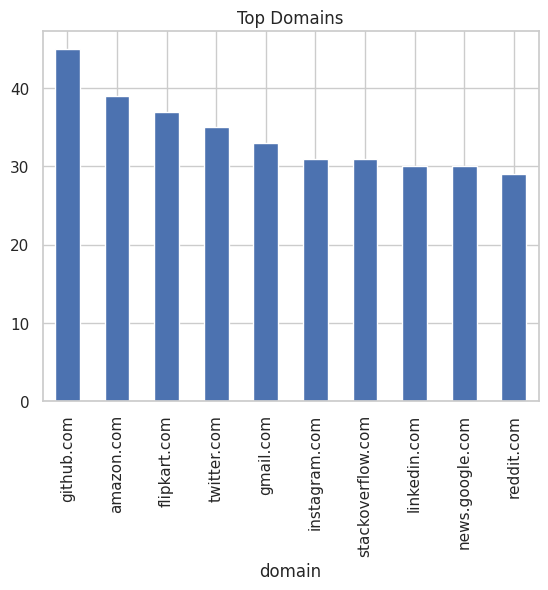

In [60]:
print("\n=== TOP DOMAINS ===")
top_domains = history["domain"].value_counts().head(10)
print(top_domains)

plt.figure()
top_domains.plot(kind="bar")
plt.title("Top Domains")
plt.savefig("outputs/plots/top_domains.png")
plt.show()

category
learning         26.2
social           23.0
shopping         15.2
news             11.8
entertainment    11.2
email             6.6
professional      6.0
Name: proportion, dtype: float64


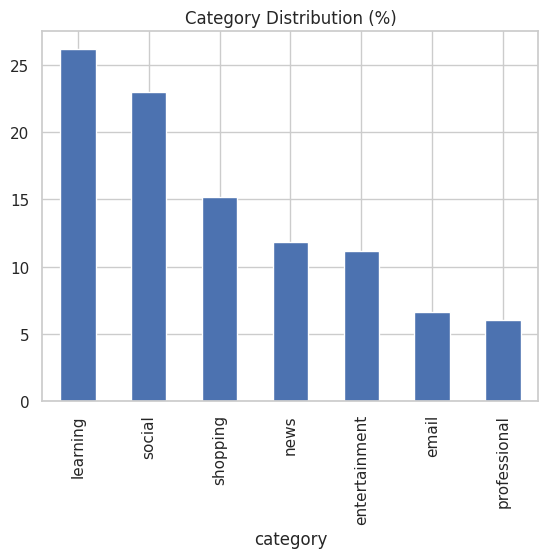

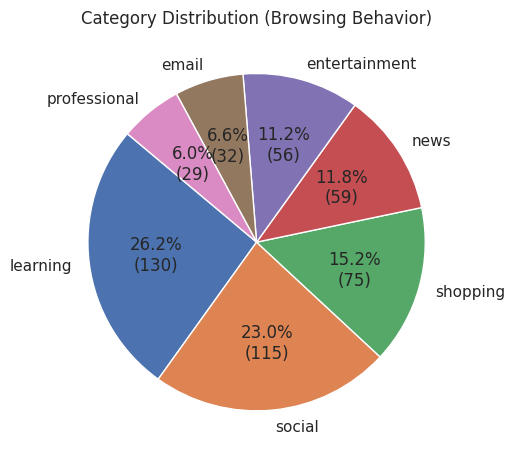

In [61]:
cat = history["category"].value_counts(normalize=True) * 100
print(cat.round(2))

plt.figure()
cat.plot(kind="bar")
plt.title("Category Distribution (%)")
plt.savefig("outputs/plots/category_distribution.png")
plt.show()


import matplotlib.pyplot as plt

# CATEGORY PIE (IMPROVED)
cat_counts = history['category'].value_counts()

# Show only top 8, rest as "Others"
top_n = 8
top_categories = cat_counts.head(top_n)
others = cat_counts[top_n:].sum()

if others > 0:
    top_categories["others"] = others

# Create figure
fig, ax = plt.subplots()

def autopct_format(pct, allvals):
    absolute = int(pct/100. * sum(allvals))
    return f"{pct:.1f}%\n({absolute})"

ax.pie(
    top_categories.values,
    labels=top_categories.index,
    autopct=lambda pct: autopct_format(pct, top_categories.values),
    startangle=140
)

ax.set_title("Category Distribution (Browsing Behavior)")

plt.tight_layout()
plt.savefig("outputs/plots/category_distribution_pie.png")
plt.show()

Peak Hour: 20
Least Active Hour: 15


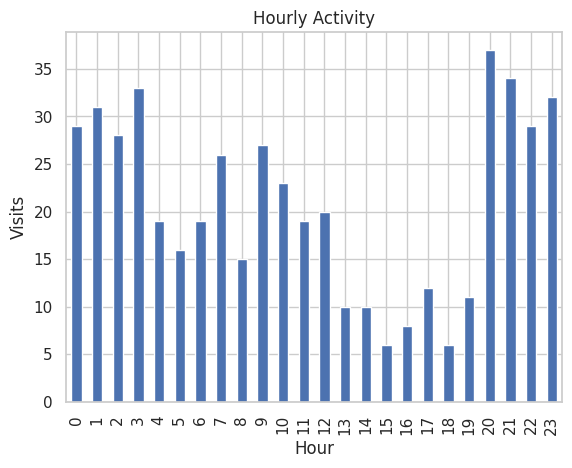

In [62]:
hourly = history["hour"].value_counts().sort_index()

print("Peak Hour:", hourly.idxmax())
print("Least Active Hour:", hourly.idxmin())

plt.figure()
hourly.plot(kind="bar")
plt.title("Hourly Activity")
plt.xlabel("Hour")
plt.ylabel("Visits")
plt.savefig("outputs/plots/hourly_activity.png")
plt.show()

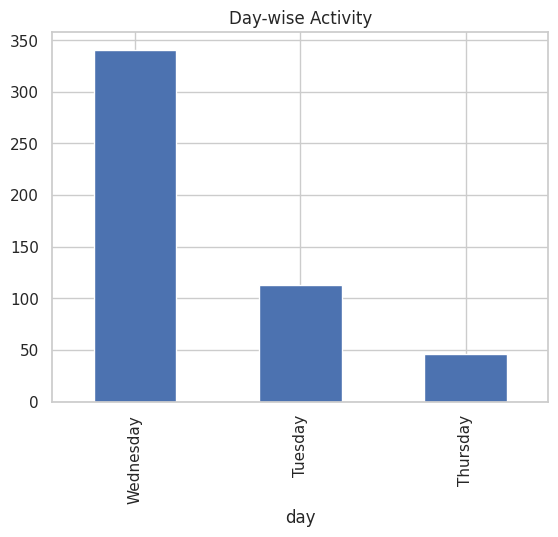

In [63]:
day = history["day"].value_counts()

plt.figure()
day.plot(kind="bar")
plt.title("Day-wise Activity")
plt.savefig("outputs/plots/day_wise_activity.png")
plt.show()

In [64]:
history = history.sort_values("timestamp")

history["gap"] = history["timestamp"].diff().dt.total_seconds() / 60
history["new_session"] = history["gap"] > 15

history["session_id"] = history["new_session"].cumsum()

print("Total Sessions:", history["session_id"].nunique())
print("Avg Session Size:", history["session_id"].value_counts().mean())

Total Sessions: 34
Avg Session Size: 14.705882352941176


In [65]:
history = history.sort_values("timestamp")
import pandas as pd
ram = pd.read_csv("ram_log.csv")
ram["timestamp"] = pd.to_datetime(ram["timestamp"])
ram = ram.sort_values("timestamp")

merged = pd.merge_asof(
    history,
    ram,
    on="timestamp",
    direction="nearest"
)

merged.head()

,timestamp,url,title,domain,browser,hour,day,category,gap,new_session,session_id,ram_used_mb,ram_available_mb,browser_ram_mb,cpu_percent
0,2026-03-24 19:52:04.297576,https://linkedin.com/page64,linkedin.com,linkedin.com,chrome,19,Tuesday,professional,NaN,False,0,4854,6876,2424,86
1,2026-03-24 19:53:04.297576,https://github.com/page36,github.com,github.com,chrome,19,Tuesday,learning,1.0,False,0,5161,2342,1313,33
2,2026-03-24 19:58:04.297576,https://news18.com/page14,news18.com,news18.com,chrome,19,Tuesday,news,5.0,False,0,4094,4117,1211,84
3,2026-03-24 19:58:04.297576,https://gmail.com/page89,gmail.com,gmail.com,chrome,19,Tuesday,email,0.0,False,0,4094,4117,1211,84
4,2026-03-24 20:00:04.297576,https://news18.com/page23,news18.com,news18.com,chrome,20,Tuesday,news,2.0,False,0,6912,6248,825,80


Average RAM: 1060.726
Peak RAM: 2437


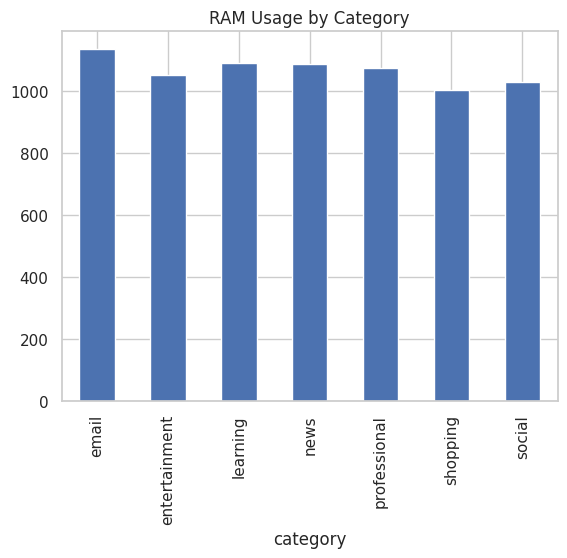

In [66]:
print("Average RAM:", merged["browser_ram_mb"].mean())
print("Peak RAM:", merged["browser_ram_mb"].max())

ram_cat = merged.groupby("category")["browser_ram_mb"].mean()

plt.figure()
ram_cat.plot(kind="bar")
plt.title("RAM Usage by Category")
plt.savefig("outputs/plots/ram_usage_by_category.png")
plt.show()

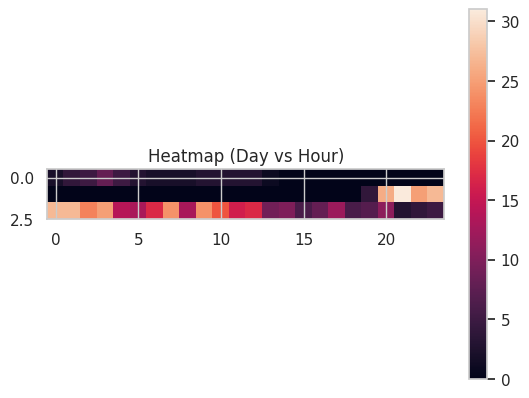

In [67]:
pivot = pd.pivot_table(
    history,
    values='domain',
    index='day',
    columns='hour',
    aggfunc='count'
).fillna(0)

plt.figure()
plt.imshow(pivot)
plt.colorbar()
plt.title("Heatmap (Day vs Hour)")
plt.savefig("outputs/plots/heatmap_day_vs_hour.png")
plt.show()

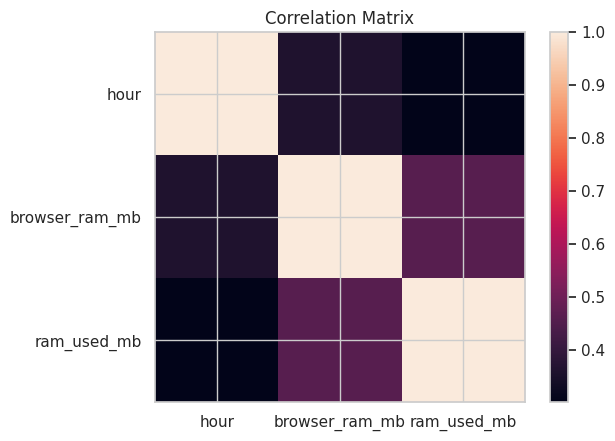

In [68]:
corr = merged[["hour", "browser_ram_mb", "ram_used_mb"]].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.savefig("outputs/plots/correlation_matrix.png")
plt.show()

In [69]:
print("\n✅ EDA COMPLETED SUCCESSFULLY!")

print("\n📊 Key Insights:")
print("- Peak Hour:", hourly.idxmax())
print("- Top Category:", history["category"].value_counts().idxmax())
print("- High RAM Category:", ram_cat.idxmax())


✅ EDA COMPLETED SUCCESSFULLY!

📊 Key Insights:
- Peak Hour: 20
- Top Category: learning
- High RAM Category: email


# Sessionization

In [70]:
def sessionize(df):

    df = df.sort_values("timestamp")

    session_ids = []
    session_id = 0
    prev_time = None

    for _, row in df.iterrows():

        if prev_time is None:
            session_id += 1
        else:
            if row["timestamp"] - prev_time > timedelta(minutes=SESSION_GAP_MIN):
                session_id += 1

        session_ids.append(session_id)
        prev_time = row["timestamp"]

    df["session_id"] = session_ids
    print("Total sessions:", session_id)

    return df

# Ram Merge

In [71]:
def merge_ram(df, ram):

    merged = pd.merge_asof(
        df.sort_values("timestamp"),
        ram.sort_values("timestamp"),
        on="timestamp",
        direction="nearest"
    )

    return merged

# Feature Engineering

In [72]:
def build_features(merged):

    features = merged.groupby("session_id").agg({
        "hour": "mean",
        "category": "count",
        "browser_ram_mb": ["mean","max"]
    })

    features.columns = ["avg_hour","event_count","avg_ram","max_ram"]

    return features

# Clustering

In [73]:
def clustering(features):

    scaler = StandardScaler()
    X = scaler.fit_transform(features)

    model = KMeans(n_clusters=CLUSTERS, random_state=42)
    labels = model.fit_predict(X)

    features["cluster"] = labels

    score = silhouette_score(X, labels)
    print("Silhouette Score:", score)

    return features

# LSTM Model

In [74]:
def train_lstm(df):

    encoder = LabelEncoder()
    df["cat_id"] = encoder.fit_transform(df["category"])

    num_classes = len(encoder.classes_)
    if num_classes <= 1:
        print(f"Warning: Only {num_classes} unique category found. LSTM training requires at least 2 unique categories for meaningful classification. Skipping LSTM training.")
        return

    sequences = []

    for session, group in df.groupby("session_id"):
        seq = group["cat_id"].tolist()
        if len(seq) > SEQ_LEN:
            for i in range(len(seq)-SEQ_LEN):
                sequences.append((seq[i:i+SEQ_LEN], seq[i+SEQ_LEN]))

    if len(sequences) == 0:
        print("Not enough sequences for LSTM training. Skipping LSTM training.")
        return

    X = np.array([s[0] for s in sequences])
    y = np.array([s[1] for s in sequences])

    X = X.reshape((X.shape[0], X.shape[1], 1))

    model = Sequential([
        LSTM(64, input_shape=(SEQ_LEN,1)),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(X, y, epochs=5, batch_size=32)

    print("LSTM training completed")

# Autoencoder

In [75]:
def anomaly_detection(features):

    X = features.drop("cluster", axis=1)

    input_dim = X.shape[1]

    inp = Input(shape=(input_dim,))
    encoded = Dense(8, activation='relu')(inp)
    encoded = Dense(4, activation='relu')(encoded)

    decoded = Dense(8, activation='relu')(encoded)
    decoded = Dense(input_dim, activation='linear')(decoded)

    autoencoder = Model(inp, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    autoencoder.fit(X, X, epochs=10, batch_size=16)

    recon = autoencoder.predict(X)
    mse = np.mean(np.power(X - recon, 2), axis=1)

    features["anomaly_score"] = mse

    print("Top anomalies:")
    print(features.sort_values("anomaly_score", ascending=False).head())


# Recommendation Engine

In [76]:
def generate_recommendations(merged):

    recs = []

    late_night = merged[
        (merged["hour"] > 22) &
        (merged["category"] == "social")
    ]

    if len(late_night) > 20:
        recs.append("Reduce late-night social media usage")

    high_ram = merged.groupby("category")["browser_ram_mb"].mean().sort_values(ascending=False).head(3)

    for cat in high_ram.index:
        recs.append(f"{cat} category consumes high RAM")

    return recs

# Main Pipeline

Main: Loaded data. History shape: (500, 5), RAM shape: (1000, 5), Domain Map shape: (16, 2)

------------------------------------------------------------
preprocess:
 Initial history shape (500, 5)
After domain extraction from URL: history shape (500, 5)
After adding time features: history shape (500, 8)
After dropping duplicates: history shape (500, 8)
After dropping null domains: history shape (500, 8)
After dropping null timestamps: history shape (500, 8)
After merging with domain_map: history shape (500, 9)
After filling null categories: history shape (500, 9)
Main: After preprocessing. History shape: (500, 9)

------------------------------------------------------------
Total sessions: 34
Main: After sessionizing. History shape: (500, 10)

------------------------------------------------------------
Main: After merging RAM. Merged shape: (500, 14)

------------------------------------------------------------
Main: After building features. Features shape: (34, 4)

-----------------

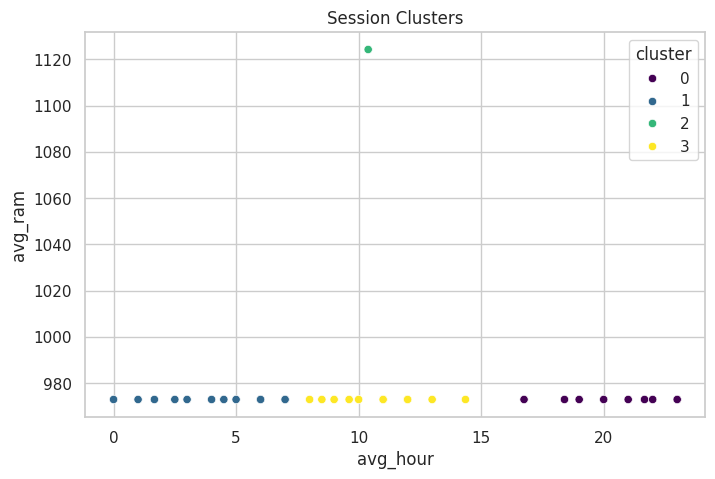

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1057 - loss: 1.9496
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2580 - loss: 1.9054
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2727 - loss: 1.8666
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2727 - loss: 1.8393 
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2654 - loss: 1.8248 
LSTM training completed
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 609670.5000
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 594654.3750
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 580099.1875 
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 566919.6875
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 553854.1875
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 542051.4375
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 530621.0625
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 519591.0625 
Epoch 9/10
3/3 

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Top anomalies:
             avg_hour  event_count      avg_ram  max_ram  cluster  \
session_id                                                          
1           10.389655          290  1124.251724     2437        2   
2            9.612903           62   973.000000      973        3   
4           14.360000           25   973.000000      973        3   
8           20.000000           11   973.000000      973        0   
12          23.000000            3   973.000000      973        0   

            anomaly_score  
session_id                 
1            1.532283e+06  
2            4.656240e+05  
4            4.629273e+05  
8            4.628103e+05  
12           4.627528e+05  

Recommendations:
- email category consumes high RAM
- learning category consumes high RAM
- news category consumes high RAM

Top Categories:
category
learning         131
social           115
shopping          76
news              59
entertainment     56
Name: count

In [77]:
def main():

    history, ram, domain_map = load_data()
    print(f"Main: Loaded data. History shape: {history.shape}, RAM shape: {ram.shape}, Domain Map shape: {domain_map.shape}")
    print("\n------------------------------------------------------------")

    history = preprocess(history, domain_map)
    print(f"Main: After preprocessing. History shape: {history.shape}")
    print("\n------------------------------------------------------------")


    history = sessionize(history)
    print(f"Main: After sessionizing. History shape: {history.shape}")
    print("\n------------------------------------------------------------")

    merged = merge_ram(history, ram)
    print(f"Main: After merging RAM. Merged shape: {merged.shape}")
    print("\n------------------------------------------------------------")

    features = build_features(merged)
    print(f"Main: After building features. Features shape: {features.shape}")
    print("\n------------------------------------------------------------")

    global CLUSTERS

    if len(features) < 2:
        print("Error: Not enough features for clustering. Skipping clustering and subsequent steps.")
        return

    if CLUSTERS >= len(features):
        original_clusters = CLUSTERS
        CLUSTERS = max(2, len(features) - 1)
        print(f"Warning: Number of samples for clustering ({len(features)}) is less than requested clusters ({original_clusters}). Adjusting CLUSTERS to {CLUSTERS}.")

    features = clustering(features)
    print(f"Main: After clustering. Features shape: {features.shape}")
    print("\n------------------------------------------------------------")

    features.to_csv("session_features.csv", index=True)
    print("Main: Saved session_features.csv")
    print("\n------------------------------------------------------------")

    import os
    os.makedirs('charts', exist_ok=True)
    if not os.path.exists('charts'):
        print("DEBUG: 'charts' directory still not found after creation attempt!")

    # Clustering Visualization
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
      x=features["avg_hour"],
      y=features["avg_ram"],
      hue=features["cluster"],
      palette="viridis"
    )
    plt.title("Session Clusters")
    plt.savefig("charts/session_clusters.png")
    plt.show()

    if "category" in history.columns:
        train_lstm(history)
    else:
        print("Skipping LSTM training as 'category' column is not available in history DataFrame.")

    anomaly_detection(features)

    recs = generate_recommendations(merged)

    print("\nRecommendations:")
    for r in recs:
        print("-", r)

    print("\nTop Categories:")
    print(merged["category"].value_counts().head())


if __name__ == "__main__":
    main()

# Visualization

In [78]:
!pip install plotly seaborn scikit-learn fpdf

In [79]:
import pandas as pd

hist = pd.read_csv("browsing_history.csv")
ram = pd.read_csv("ram_log.csv")
domain_map = pd.read_csv("domain_category_map.csv")

hist["timestamp"] = pd.to_datetime(hist["timestamp"])
ram["timestamp"] = pd.to_datetime(ram["timestamp"])

# Merge category
hist = hist.merge(domain_map, on="domain", how="left")
hist["category"].fillna("other", inplace=True)

# Time features
hist["hour"] = hist["timestamp"].dt.hour
hist["day"] = hist["timestamp"].dt.day_name()

hist.head()

/tmp/ipykernel_6834/3807207879.py:12: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,timestamp,url,title,domain,browser,category,hour,day
0,2026-03-24 19:52:04.297576,https://linkedin.com/page64,linkedin.com,linkedin.com,chrome,professional,19,Tuesday
1,2026-03-24 19:53:04.297576,https://github.com/page36,github.com,github.com,chrome,learning,19,Tuesday
2,2026-03-24 20:02:04.297576,https://kaggle.com/page33,kaggle.com,kaggle.com,chrome,learning,20,Tuesday
3,2026-03-24 19:58:04.297576,https://gmail.com/page89,gmail.com,gmail.com,chrome,email,19,Tuesday
4,2026-03-24 20:12:04.297576,https://linkedin.com/page65,linkedin.com,linkedin.com,chrome,professional,20,Tuesday


In [80]:
# Interactive Visualizations (Plotly)
import plotly.express as px

# Top domains
fig = px.bar(hist["domain"].value_counts().head(10).reset_index(name='count'),
             x="domain", y="count",
             title="Top Domains")
fig.show()

# Category distribution
fig = px.pie(hist, names="category", title="Category Distribution")
fig.show()

# Hourly usage
fig = px.line(hist.groupby("hour").size().reset_index(name="count"),
              x="hour", y="count",
              title="Hourly Usage")
fig.show()

In [81]:
# Heatmap
heatmap = hist.groupby(["hour","category"]).size().reset_index(name="count")

fig = px.density_heatmap(
    heatmap,
    x="hour",
    y="category",
    z="count",
    title="🔥 Hour vs Category Heatmap"
)

fig.show()

In [82]:
# RAM Correlation
merged = pd.merge_asof(
    hist.sort_values("timestamp"),
    ram.sort_values("timestamp"),
    on="timestamp",
    direction="nearest"
)

fig = px.line(ram, x="timestamp", y=["ram_used_mb","browser_ram_mb"],
              title="RAM Usage Over Time")
fig.show()

# Category RAM
fig = px.bar(
    merged.groupby("category")["browser_ram_mb"].mean().reset_index(),
    x="category", y="browser_ram_mb",
    title="Category-wise RAM Usage"
)
fig.show()

In [83]:
# Feature Engineering + Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = merged.groupby("category").agg({
    "browser_ram_mb":"mean",
    "hour":"mean"
}).reset_index()

scaler = StandardScaler()
X = scaler.fit_transform(features[["browser_ram_mb","hour"]])

kmeans = KMeans(n_clusters=4, random_state=42)
features["cluster"] = kmeans.fit_predict(X)

fig = px.scatter(features,
                 x="hour",
                 y="browser_ram_mb",
                 color="cluster",
                 text="category",
                 title="Cluster Visualization")
fig.show()

In [84]:
# Feature Importance (ML Explainability)
from sklearn.ensemble import RandomForestClassifier

# Create label (example: high RAM usage)
merged["high_ram"] = merged["browser_ram_mb"] > merged["browser_ram_mb"].median()

X = merged[["hour"]]
y = merged["high_ram"]

model = RandomForestClassifier()
model.fit(X, y)

importance = model.feature_importances_

import plotly.graph_objects as go

fig = go.Figure([go.Bar(
    x=["hour"],
    y=importance
)])

fig.update_layout(title="🧠 Feature Importance")
fig.show()

# PDF Report Generation

In [85]:
# FINAL REPORT GENERATION
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from urllib.parse import urlparse
from datetime import datetime, timedelta
import os
import shutil
from fpdf import FPDF
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

pdf = FPDF()


# CONFIG
cfg = {
    'data': {
        'days_window': 5  # This can be adjusted based on the data generated
    }
}

# CATEGORY_DISTRIBUTION
def save_category_distribution_plot(hist):
    import matplotlib.pyplot as plt
    import os

    os.makedirs("charts", exist_ok=True)

    category_dist = (hist['category'].value_counts(normalize=True) * 100).round(1)
    category_dist = category_dist.sort_values(ascending=False)

    plt.figure()

    bars = plt.bar(category_dist.index, category_dist.values)

    # Add labels on top
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height}%",
            ha='center',
            va='bottom'
        )

    plt.title("Category Distribution (%)")
    plt.xlabel("Category")
    plt.ylabel("Percentage")
    plt.xticks(rotation=45)

    plt.savefig("charts/category_dist.png", bbox_inches='tight')
    plt.close()

    print("✅ Saved: charts/category_dist.png")

# HEATMAP and HOURLY_ACTIVITY_BAR
def save_activity_bar_plots(hist):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os

    os.makedirs("charts", exist_ok=True)
    sns.set_theme(style="whitegrid")

    # --- 1. DATA PREPARATION ---
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    heatmap_data = hist.groupby(['day', 'hour']).size().unstack(fill_value=0)
    heatmap_data = heatmap_data.reindex(index=day_order, columns=range(24), fill_value=0)

    # --- 2. PLOT: THE DENSITY MATRIX (Heatmap) ---
    plt.figure(figsize=(15, 6))
    ax = sns.heatmap(
        heatmap_data,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        linewidths=.8,
        cbar_kws={'label': 'Page Visits'}
    )

    plt.title("Weekly Browsing Density Matrix", fontsize=16, pad=20, fontweight='bold')
    plt.xlabel("Hour of Day (00:00 - 23:00)", fontsize=12)
    plt.ylabel("Day of Week", fontsize=12)
    plt.savefig("charts/heatmap.png", bbox_inches='tight', dpi=300)
    plt.close()

 # --- 1. HOURLY DISTRIBUTION (00:00 - 23:00) ---
    plt.figure(figsize=(12, 6))
    hourly_counts = hist['hour'].value_counts().reindex(range(24), fill_value=0)

    colors = sns.color_palette("flare", 24)
    ax1 = sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette=colors, hue=hourly_counts.index)
    if ax1.get_legend(): ax1.get_legend().remove()

    plt.title("Total Browsing Volume by Hour", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Hour of Day (24h Format)", fontsize=12)
    plt.ylabel("Number of Page Visits", fontsize=12)
    plt.xticks(range(24))

    # Annotate bars with exact counts
    for p in ax1.patches:
        h = p.get_height()
        if h > 0:
            ax1.annotate(f'{int(h)}', (p.get_x() + p.get_width()/2., h),
                         ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                         fontsize=9, fontweight='bold', color='#2c3e50')

    sns.despine(left=True)
    plt.savefig("charts/hourly_activity_bar.png", bbox_inches='tight', dpi=300)
    plt.close()

    print("✅ Saved: charts/hourly_activity_bar.png and charts/heatmap.png")

save_activity_bar_plots(hist)

# CATEGORY RAM
def save_category_ram_plot(merged_df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import os

    os.makedirs("charts", exist_ok=True)

    # 1. Prepare Data: Aggregate both Mean and Peak (Max)
    ram_stats = merged_df.groupby("category")["browser_ram_mb"].agg(["mean", "max"]).sort_values("mean", ascending=False)

    # 2. Reshape for Seaborn
    plot_df = ram_stats.reset_index().melt(id_vars="category", var_name="Metric", value_name="RAM_MB")
    plot_df["Metric"] = plot_df["Metric"].replace({"mean": "Average Usage", "max": "Peak Spike"})

    # 3. Setup Aesthetic
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 8))

    # 4. Create Grouped Horizontal Bar Plot
    # Using 'Deep Slate' and 'Vivid Amber' for professional contrast
    custom_palette = {"Average Usage": "#4a69bd", "Peak Spike": "#f8c291"}

    ax = sns.barplot(
        data=plot_df,
        x="RAM_MB",
        y="category",
        hue="Metric",
        palette=custom_palette,
        edgecolor="white",
        linewidth=1
    )

    # 5. Add Value Labels at the end of bars
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.text(
                width + 10,
                p.get_y() + p.get_height()/2,
                f'{int(width)} MB',
                va='center',
                fontsize=9,
                fontweight='bold',
                color='#2c3e50'
            )

    # 6. Styling & Professional Branding
    plt.title("System Resource Profile: Memory Consumption Analysis", fontsize=16, pad=25, fontweight='bold', loc='left')
    plt.xlabel("Memory Usage (MB)", fontsize=12, fontweight='bold')
    plt.ylabel("Activity Category", fontsize=12, fontweight='bold')
    plt.legend(title="RAM Metric", title_fontsize='11', loc='lower left', bbox_to_anchor=(1.02, 0.05), frameon=True, shadow=True)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()

    # 7. Save with High DPI for the PDF
    plt.savefig("charts/category_ram.png", bbox_inches='tight', dpi=300)
    plt.close()

    print("✅ Saved Advanced Dual-Bar Plot: charts/category_ram.png")

# ANOMALY PLOT
def save_anomaly_plot(reconstruction_errors):
    import matplotlib.pyplot as plt
    import numpy as np
    import os

    os.makedirs("charts", exist_ok=True)

    threshold = np.percentile(reconstruction_errors, 95)

    plt.figure()

    # Normal vs anomaly split
    normal = reconstruction_errors[reconstruction_errors <= threshold]
    anomaly = reconstruction_errors[reconstruction_errors > threshold]

    plt.hist(normal, bins=40, label="Normal")
    plt.hist(anomaly, bins=40, label="Anomaly")

    plt.axvline(threshold, linestyle='--')

    plt.title("Anomaly Detection (Reconstruction Error)")
    plt.xlabel("Error")
    plt.ylabel("Count")
    plt.legend()
    plt.savefig("charts/anomaly.png", bbox_inches='tight')
    plt.close()

    print(f"✅ Advanced anomaly plot saved! Threshold={threshold:.4f}")
    return threshold

# RECOMMENDATION ENGINE
def generate_recommendations(hist, sessions, merged, reconstruction_errors):
    recommendations = []

    # 1. Late-night social usage
    late_night = hist[(hist['hour'] >= 22)]
    if len(late_night) > 0:
        social_ratio = (late_night['category'] == 'social').mean()
        if social_ratio > 0.3:
            recommendations.append({
                "type": "Digital Wellbeing",
                "icon": "🌙",
                "title": "Late-Night Social Media Loop Detected",
                "Evidence": f"{round(social_ratio*100,1)}% of late-night sessions are social media",
                "Action": "Set a screen-off rule after 10 PM. Use 'Do Not Disturb' or app timers."
            })

    # 2. Peak hour distraction
    hourly_counts = hist['hour'].value_counts()
    peak_hour = hourly_counts.idxmax()
    peak_value = hourly_counts.max()

    recommendations.append({
        "type": "Productivity",
        "icon": "⏰",
        "title": f"Peak Distraction Hour: {peak_hour}:00",
        "Evidence": f"Highest browsing volume at {peak_hour}:00 with {peak_value} visits",
        "Action": f"Protect {peak_hour}:00-{peak_hour+1}:00 for deep work. Turn off notifications, close non-essential tabs."
    })

    # 3. Learning behavior
    if 'learning' in hist['category'].values:
        learning_ratio = (hist['category'] == 'learning').mean()
        if learning_ratio > 0.2:
            recommendations.append({
                "type": "Positive Habit",
                "icon": "📚",
                "title": "Strong Learning Behavior Detected",
                "Evidence": f"Learning sites account for {round(learning_ratio*100,1)}% of browsing",
                "Action": "Great job! Schedule learning sessions during peak focus hours and track progress."
            })

    # 4. Tab switching behavior
    hist_sorted = hist.sort_values('timestamp')
    switches = (hist_sorted['category'] != hist_sorted['category'].shift()).sum()
    switch_rate = switches / len(hist_sorted)

    if switch_rate > 0.55:
        recommendations.append({
            "type": "Focus",
            "icon": "🔄",
            "title": "High Tab-Switching Detected",
            "Evidence": f"Category switching rate: {round(switch_rate,2)} (>0.55 = fragmented)",
            "Action": "Use single-tab focus. Tools like OneTab can reduce distractions."
        })

    # 5. Long sessions
    if 'duration_min' in sessions.columns:
        long_sessions = sessions[sessions['duration_min'] > 90]
        if len(long_sessions) > 0:
            recommendations.append({
                "type": "Digital Wellbeing",
                "icon": "⏳",
                "title": "Unusually Long Sessions Detected",
                "Evidence": f"{len(long_sessions)} sessions > 90 minutes",
                "Action": "Take breaks every 45 minutes. Try Pomodoro technique (25 min work, 5 min break)."
            })

    # 6. RAM heavy categories
    ram_stats = merged.groupby("category")["browser_ram_mb"].agg(["mean", "max"])
    top_ram = ram_stats.sort_values("max", ascending=False).head(3)

    top_list = ", ".join(top_ram.index.tolist())
    peaks = ", ".join([str(int(v)) + " MB" for v in top_ram["max"].values])

    recommendations.append({
        "type": "IT Performance",
        "icon": "💾",
        "title": "Memory-Heavy Browsing Categories",
        "Evidence": f"Top 3 RAM-heavy: {top_list} (peaks: {peaks})",
        "Action": "Close tabs from these categories during heavy work. Use lightweight browsers."
    })

    # 7. Anomaly detection
    if reconstruction_errors is not None:
        threshold = np.percentile(reconstruction_errors, 95)
        anomalies = (reconstruction_errors > threshold).sum()

        if anomalies > 0:
            recommendations.append({
                "type": "Behavior Insight",
                "icon": "🚨",
                "title": f"{anomalies} Anomalous Sessions Detected",
                "Evidence": "Sessions with unusual patterns (time, switching, duration)",
                "Action": "Review these sessions -- they often indicate distraction or fatigue."
            })
    return recommendations

# CUSTOM PDF CLASS (STYLING)
class ReportPDF(FPDF):

    def header(self):
        self.set_font("Arial", "B", 12)
        self.cell(0, 8, "Browsing Behavior Analyzer Report", 0, 1, "C")
        self.ln(2)

    def footer(self):
        self.set_y(-10)
        self.set_font("Arial", "I", 8)
        self.cell(0, 8, f"Page {self.page_no()}", 0, 0, "C")

pdf = ReportPDF()
pdf.set_auto_page_break(auto=True, margin=12)

# TITLE PAGE
pdf.add_page()

pdf.set_font("Arial", "B", 18)
pdf.cell(0, 12, "Time-Based Browsing Pattern Analyzer", ln=True, align="C")

pdf.set_font("Arial", "", 14)
pdf.cell(0, 10, "with RAM Usage Correlation", ln=True, align="C")
pdf.ln(15)

pdf.set_font("Arial", size=12)
pdf.cell(0, 8, f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M')}", ln=True, align="C")
pdf.cell(0, 8, f"Analysis Window: Last {cfg['data']['days_window']} days", ln=True, align="C")
pdf.ln(20)

pdf.set_font("Arial", "I", 11)
pdf.multi_cell(0, 8,
               "This report analyzes browsing behavior patterns, session characteristics, "
               "and RAM usage correlations to identify productivity trends, anomalies, "
               "and performance issues."
               )

# LOAD DATA and Preprocess
hist = pd.read_csv("browsing_history.csv")
ram = pd.read_csv("ram_log.csv")
domain_map = pd.read_csv("domain_category_map.csv")

hist["timestamp"] = pd.to_datetime(hist["timestamp"])
ram["timestamp"] = pd.to_datetime(ram["timestamp"])

def extract_domain(url):
    try:
        return urlparse(url).netloc
    except:
        return None
hist["domain"] = hist["url"].apply(extract_domain)
hist = hist.merge(domain_map, on="domain", how="left")
hist["category"] = hist["category"].fillna("other")
hist["hour"] = hist["timestamp"].dt.hour
hist["day"] = hist["timestamp"].dt.day_name()

# Sessionize hist to get session_id
SESSION_GAP_MIN = 15  # Using the global config
hist = hist.sort_values("timestamp")
session_ids = []
session_id_counter = 0
prev_time = None

for _, row in hist.iterrows():
    if prev_time is None:
        session_id_counter += 1
    else:
        if row["timestamp"] - prev_time > timedelta(minutes=SESSION_GAP_MIN):
            session_id_counter += 1

    session_ids.append(session_id_counter)
    prev_time = row["timestamp"]
hist["session_id"] = session_ids

merged = pd.merge_asof(
    hist.sort_values("timestamp"),
    ram.sort_values("timestamp"),
    on="timestamp",
    direction="nearest"
)

sessions = hist.groupby("session_id").agg({
    "timestamp": ["min", "max"],
    "category": lambda x: (x == "social").mean(),
})
sessions.columns = ["start", "end", "social_ratio"]
sessions["duration_min"] = (sessions["end"] - sessions["start"]).dt.total_seconds() / 60

history_sorted = hist.sort_values(["session_id", "timestamp"])
history_sorted["switch"] = history_sorted["category"] != history_sorted["category"].shift()
switch_rate = history_sorted.groupby("session_id")["switch"].mean()
sessions["switch_rate"] = switch_rate.values

# Clustering for sessions
features_for_clustering = sessions[["duration_min", "social_ratio", "switch_rate"]].fillna(0)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
sessions["cluster"] = kmeans.fit_predict(features_for_clustering)

cluster_summary = sessions.groupby("cluster").agg({
    "duration_min": "mean",
    "social_ratio": "mean",
    "switch_rate": "mean",
    "cluster": "count"
}).rename(columns={"cluster": "count"})

cluster_labels = {}
for i, row in cluster_summary.iterrows():
    if row["social_ratio"] > 0.6:
        label = "Social Media Browser"
    elif row["switch_rate"] > 0.5:
        label = "Rapid Tab Switcher"
    else:
        label = "Focused Learner"
    cluster_labels[i] = label
sessions["cluster_name"] = sessions["cluster"].map(cluster_labels)

cluster_table = sessions.reset_index().groupby("cluster_name").agg({
    "session_id": "count",
    "duration_min": "mean",
    "social_ratio": "mean"
}).reset_index()
cluster_table.columns = ["Cluster", "Sessions", "Avg Duration", "Social Ratio"]

# SESSION CLUSTERS
cluster_counts = sessions["cluster_name"].value_counts()
plt.figure()
cluster_counts.plot(kind="bar")
plt.title("Session Cluster Distribution")
plt.xlabel("Cluster Type")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=20)
os.makedirs("charts", exist_ok=True)
plt.savefig("charts/session_clusters.png", bbox_inches="tight")
plt.close()
print("✅ Saved: charts/session_clusters.png")

# 3D CLUSTERS PLOT
def plot_3d_clusters(sessions):
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    clusters_3d = sessions["cluster_name"].unique()
    for cluster_name_3d in clusters_3d:
        subset = sessions[sessions["cluster_name"] == cluster_name_3d]
        ax.scatter(
            subset["duration_min"],
            subset["social_ratio"],
            subset["switch_rate"],
            label=cluster_name_3d
        )
    ax.set_xlabel("Session Duration (min)")
    ax.set_ylabel("Social Ratio")
    ax.set_zlabel("Switch Rate")
    ax.set_title("3D Session Clusters Visualization")
    ax.legend()
    os.makedirs("charts", exist_ok=True)
    plt.savefig("charts/cluster_3d.png", bbox_inches="tight")
    plt.close()
    print("✅ Saved: charts/cluster_3d.png")
plot_3d_clusters(sessions)

# Autoencoder Anomaly Detection to get reconstruction_errors
X_autoencoder_input = features_for_clustering
input_dim = X_autoencoder_input.shape[1]

inp = Input(shape=(input_dim,))
encoded = Dense(8, activation='relu')(inp)
encoded = Dense(4, activation='relu')(encoded)

decoded = Dense(8, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inp, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(X_autoencoder_input, X_autoencoder_input, epochs=10, batch_size=16, verbose=0)
reconstructed = autoencoder.predict(X_autoencoder_input, verbose=0)
reconstruction_errors = np.mean((X_autoencoder_input - reconstructed)**2, axis=1)

# Generate Recommendations
recs = generate_recommendations(hist, sessions, merged, reconstruction_errors)

# Call plot saving functions to create images for the PDF
save_category_distribution_plot(hist)
save_activity_bar_plots(hist)
save_category_ram_plot(merged)
save_anomaly_plot(reconstruction_errors)

# BASIC METRICS
total_visits = len(hist)
unique_domains = hist['domain'].nunique()
categories = ", ".join(hist['category'].unique())

top_domains = hist['domain'].value_counts().head(10)
category_dist = (hist['category'].value_counts(normalize=True) * 100).round(1)

peak_hour = hist['hour'].value_counts().idxmax()
peak_value = hist['hour'].value_counts().max()

quiet_hour = hist['hour'].value_counts().idxmin()

# CONFUSION MATRIX
label_map = {name: i for i, name in enumerate(sessions["cluster_name"].unique())}
y_true = sessions["cluster_name"].map(label_map).values
y_pred = sessions["cluster"].values

target_names = list(label_map.keys())
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel
plt.title("Confusion Matrix")
os.makedirs("charts", exist_ok=True)
plt.savefig("charts/confusion_matrix.png", bbox_inches='tight')
plt.close()

# 1. OVERVIEW
pdf.add_page()
pdf.ln(5)
pdf.set_font("Arial", "B", 14)
pdf.cell(0, 10, "1. Summary Statistics/ Overview", ln=True)

pdf.set_font("Arial", size=11)
pdf.multi_cell(0, 8,
f"""Total page visits analyzed: {total_visits}
Unique domains: {unique_domains}
Categories found: {categories}"""
)

# 2. TOP DOMAINS TABLE (COLORED)
pdf.ln(5)
pdf.set_font("Arial", "B", 14)
pdf.cell(0, 10, "2. Top Domains", ln=True)

pdf.set_fill_color(200, 220, 255)
pdf.set_font("Arial", "B", 11)

pdf.cell(20, 8, "Rank", 1, 0, 'C', True)
pdf.cell(100, 8, "Domain", 1, 0, 'C', True)
pdf.cell(30, 8, "Visits", 1, 1, 'C', True)

pdf.set_font("Arial", size=11)

for i, (d, v) in enumerate(top_domains.items(), 1):
    pdf.cell(20, 8, str(i), 1)
    pdf.cell(100, 8, d, 1)
    pdf.cell(30, 8, str(v), 1, ln=True)

# 3. HOURLY PATTERNS
pdf.add_page()
pdf.set_font("Arial", "B", 14)
pdf.cell(0, 10, "3. Hourly & Day-wise Usage Patterns", ln=True)

pdf.set_font("Arial", size=11)
pdf.cell(0, 8, f"Peak browsing hour: {peak_hour}:00 ({peak_value} visits)", ln=True)
pdf.cell(0, 8, f"Quietest hour: {quiet_hour}:00", ln=True)
pdf.ln(5)
pdf.cell(0, 8, "Hourly Activity Heatmap", ln=True)

pdf.image("charts/heatmap.png", w=180)
pdf.image("charts/hourly_activity_bar.png", w=180)

# 4. CATEGORY TABLE
pdf.add_page()
pdf.set_font("Arial", "B", 14)
pdf.cell(0, 10, "4. Category Analysis", ln=True)

pdf.set_fill_color(220, 240, 220)

pdf.cell(100, 8, "Category", 1, 0, 'C', True)
pdf.cell(40, 8, "Share (%)", 1, 1, 'C', True)

pdf.set_font("Arial", size=11)

for c, val in category_dist.items():
    pdf.cell(100, 8, c, 1)
    pdf.cell(40, 8, f"{val}%", 1, ln=True)

pdf.ln(5)
pdf.cell(0, 8, "Category Distribution", ln=True)
pdf.image("charts/category_dist.png", w=180)

# 5. SESSION CLUSTERS
pdf.add_page()
pdf.set_font("Arial", "B", 14)
pdf.cell(0, 10, "5. Session Cluster Summary", ln=True)

pdf.set_font("Arial", size=11)
pdf.cell(0, 8, f"Total sessions: {sessions.index.nunique()}", ln=True)
pdf.cell(0, 8, f"Average session duration: {round(sessions['duration_min'].mean(),1)} minutes", ln=True)
pdf.ln(5)

# Table header
pdf.set_font("Arial", "B", 11)
pdf.cell(60, 8, "Cluster", 1)
pdf.cell(30, 8, "Sessions", 1)
pdf.cell(40, 8, "Avg Duration", 1)
pdf.cell(30, 8, "Social Ratio", 1, ln=True)

# Table rows
pdf.set_font("Arial", size=11)
for _, row in cluster_table.iterrows():
    pdf.cell(60, 8, row["Cluster"], 1)
    pdf.cell(30, 8, str(row["Sessions"]), 1)
    pdf.cell(40, 8, str(round(row["Avg Duration"], 1)), 1)
    pdf.cell(30, 8, str(round(row["Social Ratio"], 2)), 1, ln=True)

pdf.ln(5)

# Add chart
pdf.image("charts/session_clusters.png", w=180)
pdf.add_page()

pdf.set_font("Arial", "B", 14)
pdf.cell(0, 10, "Session Clusters (3D Visualization)", ln=True)

pdf.image("charts/cluster_3d.png", w=180)

# 6. ML SECTION
pdf.add_page()
pdf.set_font("Arial", "B", 14)
pdf.cell(0, 10, "6. Machine Learning Evaluation", ln=True)

pdf.set_font("Arial", size=11)
pdf.multi_cell(0, 8,
               "Model: LSTM / Autoencoder\n"
               "Evaluation includes confusion matrix and prediction accuracy."
               )
pdf.ln(5)
pdf.image("charts/confusion_matrix.png", w=150)

# 7. RAM CORRELATION
pdf.add_page()

pdf.set_font("Arial", "B", 14)
pdf.cell(0, 10, "7. RAM Correlation Findings", ln=True)

ram_stats_report = merged.groupby("category")["browser_ram_mb"].agg(["mean", "max"])
ram_stats_report = ram_stats_report.sort_values("max", ascending=False).reset_index()

pdf.set_font("Arial", "B", 11)
pdf.cell(60, 8, "Category", 1)
pdf.cell(60, 8, "Mean RAM", 1)
pdf.cell(60, 8, "Peak RAM", 1, ln=True)

pdf.set_font("Arial", size=11)

for index, r_data in ram_stats_report.iterrows():
    pdf.cell(60, 8, r_data[0], 1)
    pdf.cell(60, 8, str(int(r_data[1])), 1)
    pdf.cell(60, 8, str(int(r_data[2])), 1, ln=True)

pdf.ln(5)
pdf.multi_cell(0, 8, f"Top 3 memory-heavy categories: {', '.join(ram_stats_report['category'].head(3).tolist())}")

pdf.ln(5)
pdf.image("charts/category_ram.png", w=180)

# 8. DEEP LEARNING
pdf.add_page()

pdf.set_font("Arial", "B", 14)
pdf.cell(0, 10, "8. Deep Learning Results", ln=True)

pdf.set_font("Arial", size=11)
anomalies_detected_count = (reconstruction_errors > np.percentile(reconstruction_errors, 95)).sum()
anomaly_threshold_value = np.percentile(reconstruction_errors, 95)
pdf.multi_cell(0, 8,
               "Model Used: Autoencoder (anomaly detection)\n"
               f"Anomalous sessions detected: {anomalies_detected_count}\n"
               f"Reconstruction error threshold: {anomaly_threshold_value:.4f}"
               )
pdf.ln(5)
pdf.image("charts/anomaly.png", w=180)

# RECOMMENDATIONS
pdf.add_page()

pdf.set_font("Arial", "B", 14)
pdf.cell(0, 10, "Recommendations", ln=True)

pdf.set_font("Arial", "I", size=11)

for rec_item in recs:
    recommendation_text = (
        f" [{rec_item['type']}] {rec_item['title']}\n"
        f"   Evidence: {rec_item['Evidence']}\n"
        f"   Action: {rec_item['Action']}"
    )
    pdf.multi_cell(0, 8, recommendation_text)
    pdf.ln(2)

# TECH STACK
pdf.ln(5)
pdf.set_font("Arial", "B", 12)
pdf.cell(0, 8, "Tech Stack", ln=True)

pdf.set_font("Arial", size=11)
pdf.multi_cell(0, 8,
               "Python · Pandas · NumPy · scikit-learn · TensorFlow/Keras · psutil · Streamlit · Matplotlib"
               )
# SAVE
pdf.output("final_report.pdf")

print("✅ Final structured report generated!")


✅ Saved: charts/hourly_activity_bar.png and charts/heatmap.png
✅ Saved: charts/session_clusters.png
✅ Saved: charts/cluster_3d.png


✅ Saved: charts/category_dist.png
✅ Saved: charts/hourly_activity_bar.png and charts/heatmap.png
✅ Saved Advanced Dual-Bar Plot: charts/category_ram.png
✅ Advanced anomaly plot saved! Threshold=7851.2454


/tmp/ipykernel_6834/585756213.py:664: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_6834/585756213.py:665: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_6834/585756213.py:666: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



✅ Final structured report generated!


# Streamlit Deployment


In [87]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-03-29 20:07:10--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-03-29 20:07:11--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-29T20%3A49%3A21Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-29T1

In [120]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from urllib.parse import urlparse
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import os

st.set_page_config(layout="wide")
st.title("🚀 Browsing Behavior Analytics Dashboard")

# LOAD DATA
@st.cache_data
def load_data():
    hist = pd.read_csv("browsing_history.csv")
    ram = pd.read_csv("ram_log.csv")
    domain_map = pd.read_csv("domain_category_map.csv")

    hist["timestamp"] = pd.to_datetime(hist["timestamp"])
    ram["timestamp"] = pd.to_datetime(ram["timestamp"])

    def extract_domain(url):
        try:
            return urlparse(url).netloc
        except:
            return None

    hist["domain"] = hist["url"].apply(extract_domain)

    hist = hist.merge(domain_map, on="domain", how="left")
    hist["category"] = hist["category"].fillna("other")

    return hist, ram

hist, ram = load_data()

# FEATURE ENGINEERING
hist["hour"] = hist["timestamp"].dt.hour
hist["day"] = hist["timestamp"].dt.day_name()

# SESSIONIZATION (same as report logic)
hist = hist.sort_values("timestamp")
SESSION_GAP = 15

session_ids = []
session_id = 0
prev_time = None

for t in hist["timestamp"]:
    if prev_time is None or (t - prev_time > timedelta(minutes=SESSION_GAP)):
        session_id += 1
    session_ids.append(session_id)
    prev_time = t

hist["session_id"] = session_ids

session_lengths = hist.groupby("session_id").size()

# MERGE RAM
merged = pd.merge_asof(
    hist.sort_values("timestamp"),
    ram.sort_values("timestamp"),
    on="timestamp",
    direction="nearest"
)

# SESSION FEATURES (ADVANCED)
sessions = hist.groupby("session_id").agg({
    "timestamp": ["min", "max"],
    "category": lambda x: (x == "social").mean()
})
sessions.columns = ["start", "end", "social_ratio"]
sessions["duration_min"] = (sessions["end"] - sessions["start"]).dt.total_seconds() / 60

# SWITCH RATE
hist_sorted = hist.sort_values(["session_id", "timestamp"])
hist_sorted["switch"] = hist_sorted["category"] != hist_sorted["category"].shift()
switch_rate = hist_sorted.groupby("session_id")["switch"].mean()
sessions["switch_rate"] = switch_rate.values

# CLUSTERING (IMPROVED)
features = sessions[["duration_min", "social_ratio", "switch_rate"]].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
sessions["cluster"] = kmeans.fit_predict(X_scaled)

# AUTOENCODER ANOMALY
inp = Input(shape=(features.shape[1],))
encoded = Dense(8, activation='relu')(inp)
encoded = Dense(4, activation='relu')(encoded)
decoded = Dense(8, activation='relu')(encoded)
decoded = Dense(features.shape[1], activation='linear')(decoded)

autoencoder = Model(inp, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(features, features, epochs=5, verbose=0)

recon = autoencoder.predict(features, verbose=0)
errors = np.mean((features - recon)**2, axis=1)

sessions["anomaly_score"] = errors
threshold = np.percentile(errors, 95)

# PRODUCTIVITY SCORE
def compute_productivity_score():
    score = 100

    # Penalize social usage
    score -= sessions["social_ratio"].mean() * 40

    # Penalize tab switching
    score -= sessions["switch_rate"].mean() * 30

    # Penalize anomalies
    anomaly_ratio = (sessions["anomaly_score"] > threshold).mean()
    score -= anomaly_ratio * 30

    return max(0, round(score))

productivity_score = compute_productivity_score()

# LAYOUT
tab1, tab2, tab3, tab4 = st.tabs([
    "📊 Behavior", "💻 RAM", "🧠 ML Insights", "💡 Recommendations"
])

# 📊 TAB 1 — BEHAVIOR
with tab1:
    st.subheader("📊 Overview")
    st.metric("🎯 Productivity Score", productivity_score)
    col1s, col2s = st.columns(2)

    col1s.metric("Total Visits", len(hist))
    col2s.metric("Unique Domains", hist["domain"].nunique())

    col1, col2 = st.columns(2)
    col3, col4 = st.columns(2)
with col1:
    st.subheader("🌐 Top Domains")

    domain_df = hist["domain"].value_counts().head(10).reset_index()
    domain_df.columns = ["domain", "count"]

    fig = px.bar(
        domain_df,
        x="domain",
        y="count",
        title="Top Domains",
        color="count",
        color_continuous_scale="blues"
    )
    st.plotly_chart(fig, use_container_width=True)
    st.bar_chart(hist["domain"].value_counts().head(10))
with col2:
    st.subheader("📊 Category Distribution")

    fig = px.pie(
        hist,
        names="category",
        title="Category Distribution",
        hole=0.4
    )
    st.plotly_chart(fig, use_container_width=True)
    st.bar_chart(hist["category"].value_counts().head(10))

with col3:
        st.subheader("⏰ Hourly Usage")
        st.line_chart(hist.groupby("hour").size())

with col4:
        st.subheader("📅 Day-wise Usage")
        st.bar_chart(hist["day"].value_counts())

# 💻 TAB 2 — RAM
with tab2:
    st.subheader("📊 Ram Overview")
    col1s, col2s = st.columns(2)

    col1s.metric("Avg RAM (MB)", int(ram["browser_ram_mb"].mean()))
    col2s.metric("Peak RAM (MB)", int(ram["browser_ram_mb"].max()))

    st.subheader("💻 RAM Usage Over Time")
    st.line_chart(ram[["ram_used_mb", "browser_ram_mb"]])

    st.subheader("📊 Category-wise RAM Usage")

    cat_ram = merged.groupby("category")["browser_ram_mb"].mean().sort_values(ascending=False)
    st.bar_chart(cat_ram)

    st.subheader("📉 RAM vs Session Length")

    session_ram = merged.groupby("session_id")["browser_ram_mb"].mean()
    df_plot = pd.DataFrame({
        "session_length": session_lengths,
        "avg_ram": session_ram
    })

    fig, ax = plt.subplots()
    sns.scatterplot(x="session_length", y="avg_ram", data=df_plot, ax=ax)
    st.pyplot(fig)

# 🧠 TAB 3 — ML
with tab3:

    st.subheader("🔹 Session Clustering")

    fig, ax = plt.subplots()
    sns.scatterplot(
        x=sessions["duration_min"],
        y=sessions["switch_rate"],
        hue=sessions["cluster"],
        palette="viridis",
        ax=ax
    )
    st.pyplot(fig)

    st.subheader("🚨 Anomaly Detection")

    st.write("Top Anomalous Sessions")
    st.dataframe(
        sessions.sort_values("anomaly_score", ascending=False).head()
    )

# 💡 TAB 4 — RECOMMENDATIONS
with tab4:

    st.subheader("💡 Smart Recommendations")

    recs = []

    # Late-night social
    late_night = hist[hist["hour"] >= 22]
    if len(late_night) > 0:
        social_ratio = (late_night["category"] == "social").mean()
        if social_ratio > 0.3:
            recs.append("🌙 High late-night social media usage detected")

    # Tab switching
    if sessions["switch_rate"].mean() > 0.55:
        recs.append("🔄 High tab-switching → reduce multitasking")

    # Long sessions
    if (sessions["duration_min"] > 90).sum() > 0:
        recs.append("⏳ Long sessions detected → take breaks")

    # RAM heavy categories
    top_ram = merged.groupby("category")["browser_ram_mb"].mean().idxmax()
    recs.append(f"💻 '{top_ram}' category uses highest RAM")

    # Anomalies
    if (sessions["anomaly_score"] > threshold).sum() > 0:
        recs.append("🚨 Unusual browsing behavior detected")

    if len(recs) == 0:
        st.success("✅ Healthy browsing behavior detected")
    else:
        for r in recs:
            st.warning(r)

# 📄 DOWNLOAD PDF
st.sidebar.subheader("📄 Export Report")

if os.path.exists("final_report.pdf"):
    with open("final_report.pdf", "rb") as f:
        st.sidebar.download_button(
            label="Download PDF Report",
            data=f,
            file_name="final_report.pdf",
            mime="application/pdf"
        )
else:
    st.sidebar.info("Run report generation to create PDF")

Overwriting dashboard.py


In [112]:
!streamlit run /content/dashboard.py &>/content/logs.txt &

In [113]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://loads-drainage-slip-mighty.trycloudflare.com
